In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Model Execution and Training

#### Imports

In [20]:
import pandas as pd
import sys
import os

sys.path.append('../')
from src.data.loader import load_raw_data
import src.features.mandatory as mandatory
from src.features.custom import build_custom_features
from src.data.splitter import perform_stratified_split
from src.pipelines.preprocessing import build_preprocessor,preprocess_data
from src.models.baseline import get_majority_class_baseline
from src.models.classifiers import get_knn_model, get_adaboost_model, get_random_forest_model

#### Preprocessing & Splitting 

In [21]:
sys.path.append(os.path.abspath(os.path.join('..')))

#Load the data into a DataFrame variable
df_ = load_raw_data()

# adding features
df = mandatory.fill_missing_text(df_)

df_Mfeatures = mandatory.build_mandatory_features(df)

df_features = build_custom_features(df_Mfeatures)
print(f"Data shape after feature engineering: {df_features.shape}")

X_train_processed, X_val_processed, X_test_processed, y_train, y_val, y_test = preprocess_data(df_features)

print(f"Train size: {len(X_train_processed)} | Val size: {len(X_val_processed)} | Test size: {len(X_test_processed)}")
print(f"Train matrix shape: {X_train_processed.shape}")
print(f"Validation matrix shape: {X_val_processed.shape}")
print(f"Test matrix shape: {X_test_processed.shape}")

Successfully located and loaded raw data from: data/raw/agent_tool_tasks.csv
Data shape after feature engineering: (3491, 43)
Train size: 2792 | Val size: 349 | Test size: 350
Train matrix shape: (2792, 48)
Validation matrix shape: (349, 48)
Test matrix shape: (350, 48)


#### Initialize and Train Models

In [22]:
baseline = get_majority_class_baseline()
baseline.fit(X_train_processed, y_train)

# 2. K-Nearest Neighbors
knn = get_knn_model(n_neighbors=5)
knn.fit(X_train_processed, y_train)

# 3. AdaBoost
adaboost = get_adaboost_model()
adaboost.fit(X_train_processed, y_train)

# 4. Random Forest
rf = get_random_forest_model()
rf.fit(X_train_processed, y_train)

print("All models successfully trained.")

All models successfully trained.


# Tuning & Evaluating

#### Setup & Imports for Tuning and Evaluation

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import ParameterGrid
from src.evaluation.visualization import plot_confusion_matrices, plot_metric_comparison

# Helper function to tune manually strictly on the Validation set
def tune_model(model_class, param_grid, is_random_state_needed=True):
    best_f1 = -1
    best_params = None
    best_model = None
    
    for params in ParameterGrid(param_grid):
        # Initialize model with current parameters
        if is_random_state_needed:
            model = model_class(**params, random_state=42)
        else:
            model = model_class(**params)
            
        # Fit on Training Set
        model.fit(X_train_processed, y_train)
        
        # Evaluate strictly on Validation Set
        y_val_pred = model.predict(X_val_processed)
        current_f1 = f1_score(y_val, y_val_pred)
        
        # Save best configuration
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_params = params
            best_model = model
            
    return best_model, best_params

### Hyperparameter Tuning

In [24]:
# 1. Tune K-Nearest Neighbors
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}
best_knn, knn_params = tune_model(get_knn_model, knn_grid, is_random_state_needed=False)
print(f"Best KNN Params: {knn_params}")

# 2. Tune AdaBoost
ada_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.1, 0.5, 1.0]
}
best_ada, ada_params = tune_model(get_adaboost_model, ada_grid)
print(f"Best AdaBoost Params: {ada_params}")

# 3. Tune Random Forest
rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20]
}
best_rf, rf_params = tune_model(get_random_forest_model, rf_grid)
print(f"Best Random Forest Params: {rf_params}")

Best KNN Params: {'n_neighbors': 9, 'weights': 'uniform'}
Best AdaBoost Params: {'learning_rate': 1.0, 'n_estimators': 200}
Best Random Forest Params: {'max_depth': 20, 'n_estimators': 50}


### Evaluation on test Set

In [27]:
final_models = {
    'Baseline': baseline, # Created in previous step
    'KNN': best_knn,
    'AdaBoost': best_ada,
    'Random Forest': best_rf
}

metrics_list = []

print("\n--- Final Test Set Results ---")
for name, model in final_models.items():
    # Final predict on the untouched test set
    y_test_pred = model.predict(X_test_processed)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)
    
    metrics_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    
    print(f"{name}: Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}")

# Convert to DataFrame for easy plotting
metrics_df = pd.DataFrame(metrics_list).set_index('Model')


--- Final Test Set Results ---
Baseline: Acc=0.6771 | Prec=0.6771 | Rec=1.0000 | F1=0.8075
KNN: Acc=0.8343 | Prec=0.8510 | Rec=0.9156 | F1=0.8821
AdaBoost: Acc=0.8743 | Prec=0.8939 | Rec=0.9241 | F1=0.9087
Random Forest: Acc=0.8943 | Prec=0.8968 | Rec=0.9536 | F1=0.9243


### Visualizations

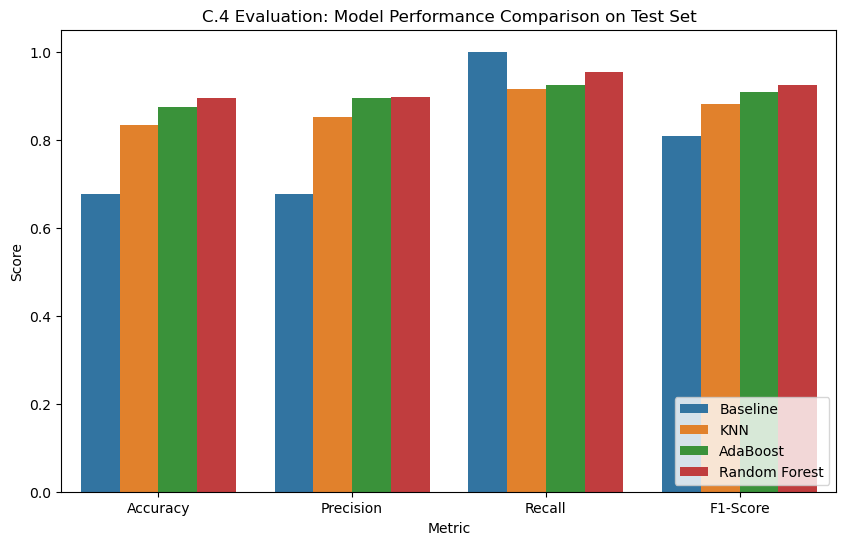

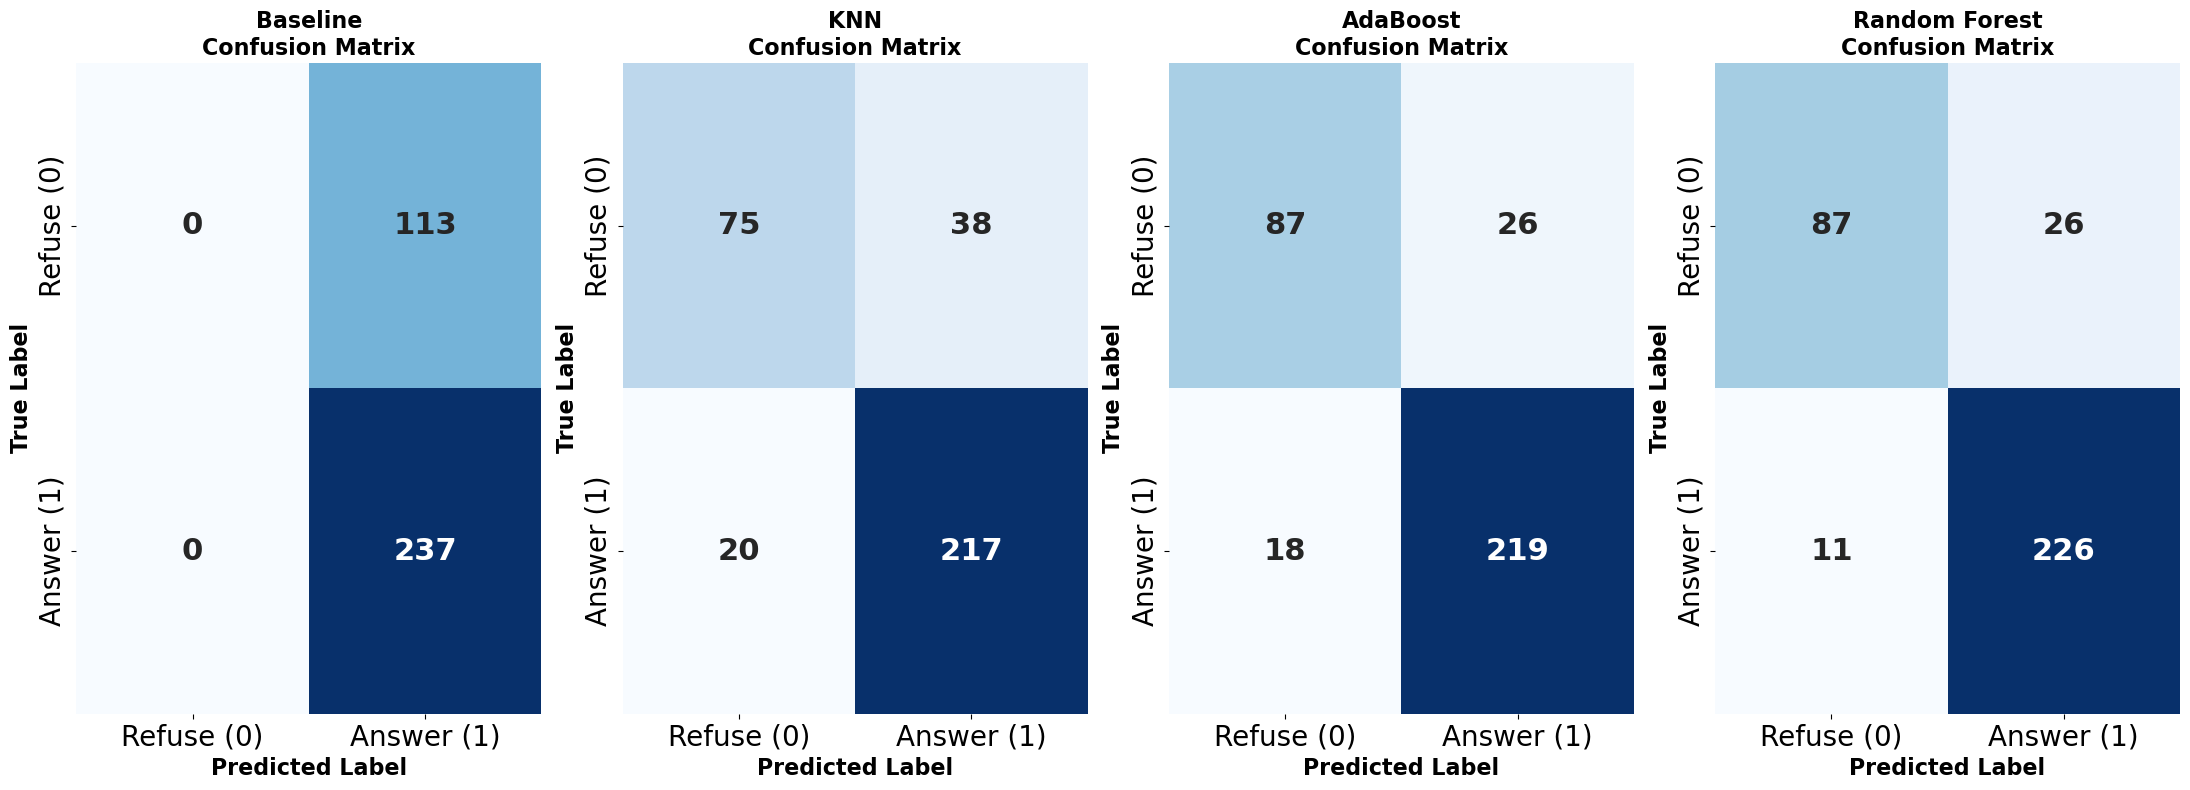

In [42]:
# 1. Comparison Plot
plot_metric_comparison(metrics_df)

# 2. Confusion Matrices
plot_confusion_matrices(final_models, X_test_processed, y_test)